In [1]:
!pip install rasterio tqdm cupy-cuda12x --quiet
# cupy-cuda12x es para CUDA 12.x (Colab actual)
# Si falla, prueba: cupy-cuda11x

import os, time
import numpy as np
import rasterio
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import kagglehub
from pathlib import Path
warnings.filterwarnings("ignore")

# ── Detectar GPU y cargar CuPy ───────────────────────────────────────────────
try:
    import cupy as cp
    _ = cp.array([1.0])          # prueba real de que la GPU responde
    xp = cp                      # xp = "array module" activo
    GPU_OK = True
    print(f" GPU detectada: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
    print(f"   Memoria libre : {cp.cuda.runtime.memGetInfo()[0]/1e9:.1f} GB")
except Exception as e:
    xp = np
    GPU_OK = False
    print(f"  CuPy no disponible ({e}). Usando NumPy (CPU).")

✅ GPU detectada: Tesla T4
   Memoria libre : 15.5 GB


PATHS

In [2]:

# Download latest version
path = kagglehub.dataset_download("gallo33henrique/sentinel-2-satellite-imagery")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentinel-2-satellite-imagery' dataset.
Path to dataset files: /kaggle/input/sentinel-2-satellite-imagery


In [3]:


# Buscar todos los .tif
DATASET_PATH = Path(path)
tif_files = sorted(DATASET_PATH.glob("**/*.tif"))

print(f"\n Archivos .tif encontrados: {len(tif_files)}")
if tif_files:
    print(f"   Primero : {tif_files[0].name}")
    print(f"   Último  : {tif_files[-1].name}")
else:
    # Si no encontró, mostrar qué hay en el path
    for root, dirs, files in os.walk(DATASET_PATH):
        nivel = str(root).replace(str(DATASET_PATH), '').count(os.sep)
        if nivel > 4:
            dirs.clear()
            continue
        print(f"{'  '*nivel}{os.path.basename(root)}/")
        for f in files[:3]:
            print(f"{'  '*nivel}   📄 {f}")


✅ Archivos .tif encontrados: 27000
   Primero : AnnualCrop_1.tif
   Último  : SeaLake_999.tif


In [4]:
BAND_MAP = {
    "Blue":  1,
    "Green": 2,
    "Red":   3,
    "NIR":   7,
    "SWIR1": 11,
    "SWIR2": 12,
}

def leer_bandas(path: Path) -> dict | None:
    """
    Lee las 6 bandas del .tif en CPU (rasterio no soporta GPU),
    luego sube los arrays a GPU con cp.asarray().
    """
    try:
        with rasterio.open(path) as src:
            raw = src.read()                         # (13, 64, 64) uint16 — CPU
    except Exception:
        return None

    bandas = {}
    for nombre, idx in BAND_MAP.items():
        b = raw[idx].astype(np.float32) / 10_000.0  # normalizar en CPU
        b = np.clip(b, 0.0, 1.0)
        bandas[nombre] = xp.asarray(b)              # ← subir a GPU si xp=cupy
    return bandas


def indice_normalizado(a, b):
    """
    (a - b) / (a + b) — opera sobre arrays CuPy (GPU) o NumPy (CPU).
    xp.where maneja división por cero sin warnings.
    """
    denom = a + b
    result = xp.where(denom == 0.0, 0.0, (a - b) / denom)
    return result.astype(xp.float32)

In [5]:
def calcular_indices(bandas: dict) -> dict:
    """
    Calcula los 4 índices espectrales en GPU (o CPU si no hay GPU).
    Entrada : dict de bandas como arrays CuPy/NumPy (float32, rango [0,1])
    Salida  : dict {"NDVI": array, "NDWI": array, "NDBI": array, "NBR": array}
    """
    # 1. NDVI — Vegetación: (NIR - Red) / (NIR + Red)
    ndvi = indice_normalizado(bandas["NIR"], bandas["Red"])

    # 2. NDWI — Agua: (Green - NIR) / (Green + NIR)
    ndwi = indice_normalizado(bandas["Green"], bandas["NIR"])

    # 3. NDBI — Áreas construidas: (SWIR1 - NIR) / (SWIR1 + NIR)
    ndbi = indice_normalizado(bandas["SWIR1"], bandas["NIR"])

    # 4. NBR — Área quemada: (NIR - SWIR2) / (NIR + SWIR2)
    nbr  = indice_normalizado(bandas["NIR"], bandas["SWIR2"])

    return {"NDVI": ndvi, "NDWI": ndwi, "NDBI": ndbi, "NBR": nbr}

PRUEBA VISUAL

🔬 Prueba con: AnnualCrop_1.tif

  NDVI  min=0.0797  max=0.4913  mean=0.1888  shape=(64, 64)
  NDWI  min=-0.5052  max=-0.1230  mean=-0.2402  shape=(64, 64)
  NDBI  min=-0.2677  max=0.2541  mean=0.0689  shape=(64, 64)
  NBR  min=-0.1982  max=0.0616  mean=-0.0755  shape=(64, 64)


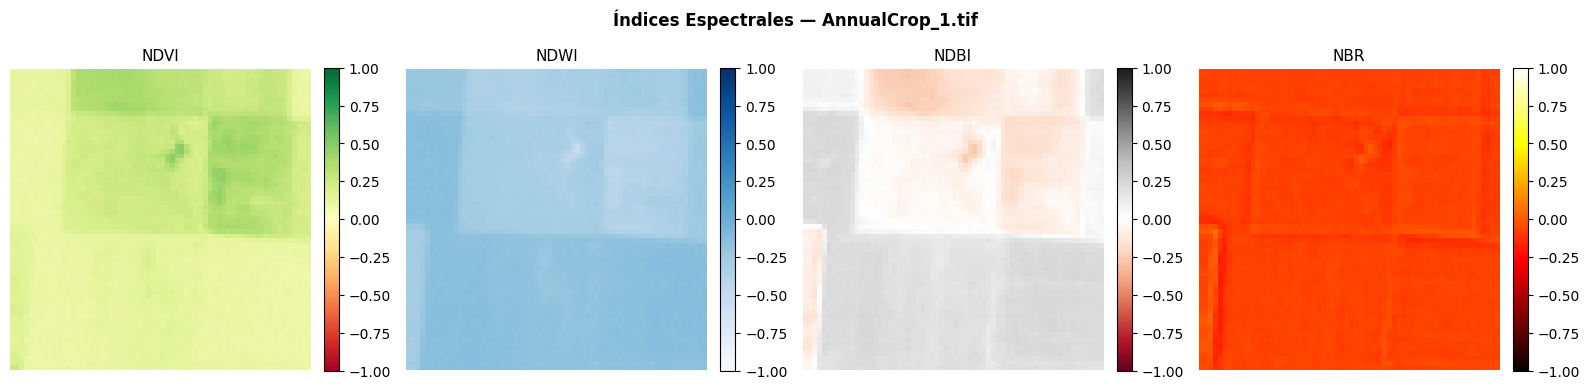

✅ Guardado: /content/indices_muestra.png


In [6]:
sample = tif_files[0]
bandas_test = leer_bandas(sample)
indices_test = calcular_indices(bandas_test)

print(f" Prueba con: {sample.name}\n")
for nombre, arr in indices_test.items():
    # .get() baja el array de GPU a CPU para numpy/matplotlib
    arr_cpu = cp.asnumpy(arr) if GPU_OK else arr
    print(f"  {nombre}  min={arr_cpu.min():.4f}  max={arr_cpu.max():.4f}  "
          f"mean={arr_cpu.mean():.4f}  shape={arr_cpu.shape}")

# Visualización de los 4 índices
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colormaps = {"NDVI": "RdYlGn", "NDWI": "Blues", "NDBI": "RdGy", "NBR": "hot"}
fig.suptitle(f"Índices Espectrales — {sample.name}", fontweight='bold')

for ax, (nombre, arr) in zip(axes, indices_test.items()):
    arr_cpu = cp.asnumpy(arr) if GPU_OK else arr   # matplotlib necesita numpy
    im = ax.imshow(arr_cpu, cmap=colormaps[nombre], vmin=-1, vmax=1)
    ax.set_title(nombre, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("/content/indices_muestra.png", dpi=130, bbox_inches='tight')
plt.show()
print(" Guardado: /content/indices_muestra.png")

OUTPUT

In [7]:
OUTPUT_DIR = Path("/content/indices_output")
OUTPUT_DIR.mkdir(exist_ok=True)

def guardar_indices(ruta_origen: Path, indices: dict, output_dir: Path):
    """
    Baja los arrays de GPU a CPU y guarda los 4 índices como .tif de 4 bandas.
    rasterio solo escribe NumPy, así que cp.asnumpy() es obligatorio aquí.
    """
    nombre_salida = ruta_origen.stem + "_indices.tif"
    ruta_salida   = output_dir / nombre_salida

    with rasterio.open(ruta_origen) as src:
        perfil = src.profile

    perfil.update(
        count=4,
        dtype=rasterio.float32,
        compress='lzw'
    )

    with rasterio.open(ruta_salida, 'w', **perfil) as dst:
        for i, (nombre, arr) in enumerate(indices.items(), start=1):
            # ← bajar de GPU a CPU solo en el momento de escribir
            arr_cpu = cp.asnumpy(arr) if GPU_OK else arr
            dst.write(arr_cpu, i)
            dst.update_tags(i, name=nombre)

    return ruta_salida


# Prueba rápida con la imagen de muestra
ruta_guardada = guardar_indices(sample, indices_test, OUTPUT_DIR)
print(f" Guardado en: {ruta_guardada}")
print(f"   Tamaño: {ruta_guardada.stat().st_size / 1024:.1f} KB")

with rasterio.open(ruta_guardada) as check:
    print(f"   Bandas escritas: {check.count}")
    print(f"   Tags banda 1: {check.tags(1)}")

✅ Guardado en: /content/indices_output/AnnualCrop_1_indices.tif
   Tamaño: 73.7 KB
   Bandas escritas: 4
   Tags banda 1: {'name': 'NDVI'}


GPU

In [10]:
import logging
logging.getLogger("rasterio._env").setLevel(logging.ERROR)

BATCH_SIZE = 256   # T4 tiene 15GB, 256 imágenes de 64x64 caben fácil

def leer_batch_cpu(paths: list[Path]) -> tuple[np.ndarray, list[Path], list[Path]]:
    """
    Lee N imágenes en CPU puro y las apila en un array (N, 13, 64, 64).
    Retorna el array, paths válidos y paths con error.
    """
    arrays  = []
    validos = []
    errores = []
    for p in paths:
        try:
            with rasterio.open(p) as src:
                arrays.append(src.read())   # (13, 64, 64) uint16
            validos.append(p)
        except Exception:
            errores.append(p)
    return np.stack(arrays).astype(np.float32), validos, errores


def calcular_indices_batch(raw_gpu: cp.ndarray) -> dict:
    """
    raw_gpu : (N, 13, 64, 64) float32 ya en GPU, valores /10000
    Retorna dict con arrays (N, 64, 64) para cada índice.
    """
    # Extraer bandas — todas en GPU de una vez
    Blue  = raw_gpu[:, 1,  :, :]
    Green = raw_gpu[:, 2,  :, :]
    Red   = raw_gpu[:, 3,  :, :]
    NIR   = raw_gpu[:, 7,  :, :]
    SWIR1 = raw_gpu[:, 11, :, :]
    SWIR2 = raw_gpu[:, 12, :, :]

    def norm(a, b):
        denom = a + b
        return cp.where(denom == 0.0, 0.0, (a - b) / denom).astype(cp.float32)

    return {
        "NDVI": norm(NIR, Red),
        "NDWI": norm(Green, NIR),
        "NDBI": norm(SWIR1, NIR),
        "NBR" : norm(NIR, SWIR2),
    }


def guardar_batch(indices: dict, paths: list[Path], output_dir: Path):
    """
    Baja resultados de GPU a CPU y guarda cada imagen.
    indices: dict con arrays (N, 64, 64)
    """
    # Bajar TODO de GPU a CPU en un solo transfer
    indices_cpu = {k: cp.asnumpy(v) for k, v in indices.items()}
    N = len(paths)

    for i, path in enumerate(paths):
        with rasterio.open(path) as src:
            perfil = src.profile

        perfil.update(count=4, dtype=rasterio.float32, compress='lzw',
                      tiled=True, blockxsize=64, blockysize=64)

        ruta_salida = output_dir / (path.stem + "_indices.tif")
        with rasterio.open(ruta_salida, 'w', **perfil) as dst:
            for j, nombre in enumerate(["NDVI", "NDWI", "NDBI", "NBR"]):
                dst.write(indices_cpu[nombre][i], j + 1)
                dst.update_tags(j + 1, name=nombre)


# ── Loop principal ────────────────────────────────────────────────────────────
ya_procesados = {f.stem.replace("_indices", "") for f in OUTPUT_DIR.glob("*.tif")}
pendientes    = [f for f in tif_files if f.stem not in ya_procesados]

print(f" Total      : {len(tif_files)}")
print(f" Ya listos  : {len(ya_procesados)}")
print(f" Pendientes : {len(pendientes)}")
print(f"   Batch size : {BATCH_SIZE} imágenes\n")

errores  = []
t_inicio = time.time()
batches  = [pendientes[i:i+BATCH_SIZE] for i in range(0, len(pendientes), BATCH_SIZE)]

for batch in tqdm(batches, desc="Batches GPU", unit="batch"):
    # 1. Leer disco → RAM (CPU)
    raw_np, validos, errs = leer_batch_cpu(batch)
    errores += errs
    if len(validos) == 0:
        continue

    # 2. Normalizar y subir a GPU en un solo transfer
    raw_gpu = cp.asarray(raw_np / 10_000.0)
    raw_gpu = cp.clip(raw_gpu, 0.0, 1.0)
    del raw_np   # liberar RAM inmediatamente

    # 3. Calcular 4 índices para TODO el batch en GPU
    indices = calcular_indices_batch(raw_gpu)
    del raw_gpu  # liberar VRAM

    # 4. Bajar a CPU y guardar
    guardar_batch(indices, validos, OUTPUT_DIR)

t_total = time.time() - t_inicio
procesadas = len(pendientes) - len(errores)

print(f"\n Procesadas  : {procesadas}")
print(f" Errores     : {len(errores)}")
print(f"  Tiempo      : {t_total:.1f} seg  ({t_total/60:.1f} min)")
print(f"   Por imagen  : {t_total/max(procesadas,1)*1000:.1f} ms")
print(f"Generados   : {len(list(OUTPUT_DIR.glob('*.tif')))}")

🚀 Total      : 27000
✅ Ya listos  : 0
⏳ Pendientes : 27000
   Batch size : 256 imágenes



Batches GPU: 100%|██████████| 106/106 [09:40<00:00,  5.47s/batch]



✅ Procesadas  : 27000
❌ Errores     : 0
⏱  Tiempo      : 580.2 seg  (9.7 min)
   Por imagen  : 21.5 ms
📁 Generados   : 27000


verison 2

In [11]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import logging
logging.getLogger("rasterio._env").setLevel(logging.ERROR)

BATCH_SIZE  = 512
N_WRITE_WORKERS = 16  # hilos para escritura paralela

# ── Lectura paralela ──────────────────────────────────────────────────────────
def leer_una(path: Path):
    try:
        with rasterio.open(path) as src:
            return path, src.read(), src.profile
    except Exception:
        return path, None, None

def leer_batch_paralelo(paths: list[Path]):
    arrays, validos, perfiles, errores = [], [], [], []
    with ThreadPoolExecutor(max_workers=16) as ex:
        futuros = {ex.submit(leer_una, p): p for p in paths}
        for f in as_completed(futuros):
            path, raw, perfil = f.result()
            if raw is None:
                errores.append(path)
            else:
                arrays.append(raw)
                validos.append(path)
                perfiles.append(perfil)
    return np.stack(arrays).astype(np.float32), validos, perfiles, errores

# ── Escritura paralela ────────────────────────────────────────────────────────
def escribir_una(args):
    path, perfil, output_dir, ndvi, ndwi, ndbi, nbr = args
    perfil.update(count=4, dtype=rasterio.float32, compress='lzw',
                  tiled=True, blockxsize=64, blockysize=64)
    ruta_salida = output_dir / (path.stem + "_indices.tif")
    with rasterio.open(ruta_salida, 'w', **perfil) as dst:
        for j, (nombre, arr) in enumerate(
                zip(["NDVI","NDWI","NDBI","NBR"], [ndvi, ndwi, ndbi, nbr]), start=1):
            dst.write(arr, j)
            dst.update_tags(j, name=nombre)

def guardar_batch_paralelo(indices_cpu: dict, paths: list[Path],
                           perfiles: list, output_dir: Path):
    N = len(paths)
    args = [
        (paths[i], perfiles[i], output_dir,
         indices_cpu["NDVI"][i], indices_cpu["NDWI"][i],
         indices_cpu["NDBI"][i], indices_cpu["NBR"][i])
        for i in range(N)
    ]
    with ThreadPoolExecutor(max_workers=N_WRITE_WORKERS) as ex:
        list(ex.map(escribir_una, args))

# ── Cálculo GPU (igual que antes) ────────────────────────────────────────────
def calcular_indices_batch(raw_gpu: cp.ndarray) -> dict:
    Blue  = raw_gpu[:, 1,  :, :]
    Green = raw_gpu[:, 2,  :, :]
    Red   = raw_gpu[:, 3,  :, :]
    NIR   = raw_gpu[:, 7,  :, :]
    SWIR1 = raw_gpu[:, 11, :, :]
    SWIR2 = raw_gpu[:, 12, :, :]

    def norm(a, b):
        denom = a + b
        return cp.where(denom == 0.0, 0.0, (a - b) / denom).astype(cp.float32)

    return {
        "NDVI": norm(NIR, Red),
        "NDWI": norm(Green, NIR),
        "NDBI": norm(SWIR1, NIR),
        "NBR" : norm(NIR, SWIR2),
    }

# ── Loop principal ────────────────────────────────────────────────────────────
# Forzar reprocesar todo
OUTPUT_DIR = Path("/content/indices_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f" Procesando {len(tif_files)} imágenes")
print(f"   Batch size : {BATCH_SIZE} | Write workers: {N_WRITE_WORKERS}\n")

errores  = []
t_inicio = time.time()
batches  = [tif_files[i:i+BATCH_SIZE] for i in range(0, len(tif_files), BATCH_SIZE)]

for batch in tqdm(batches, desc="Batches GPU", unit="batch"):
    # 1. Lectura paralela en CPU
    raw_np, validos, perfiles, errs = leer_batch_paralelo(batch)
    errores += errs
    if len(validos) == 0:
        continue

    # 2. Subir a GPU, normalizar, calcular
    raw_gpu = cp.clip(cp.asarray(raw_np / 10_000.0), 0.0, 1.0)
    del raw_np

    indices = calcular_indices_batch(raw_gpu)
    del raw_gpu

    # 3. Bajar a CPU todo de

🚀 Procesando 27000 imágenes
   Batch size : 512 | Write workers: 16



Batches GPU: 100%|██████████| 53/53 [01:44<00:00,  1.97s/batch]
